# Performance Analytics — Day 4 Deliverable
**Bluestock Fintech Capstone | Mutual Fund Analytics Platform**

---

## Setup & Data Load

In [8]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')



fm    = pd.read_csv('clean_01_fund_master.csv')
nav   = pd.read_csv('clean_02_nav_history.csv', parse_dates=['date'])
bench = pd.read_csv('clean_10_benchmark_indices.csv', parse_dates=['date'])

nav   = nav.sort_values(['amfi_code','date'])
Rf    = 0.065 / 252  # Daily risk-free rate (6.5% RBI repo proxy)

print(f"NAV rows: {len(nav):,} | Funds: {nav['amfi_code'].nunique()} | Date range: {nav['date'].min().date()} to {nav['date'].max().date()}")


NAV rows: 64,320 | Funds: 40 | Date range: 2022-01-03 to 2026-05-29


## Task 1 — Daily Returns & Annualised Return
`daily_return = nav_t / nav_t-1 - 1`  |  `annualised = (1 + daily_return).prod()^(252/n) - 1`

In [9]:

from google.colab import drive
drive.mount('/content/drive')
OUT = '/content/drive/MyDrive/output/'
import os
os.makedirs(OUT, exist_ok=True)

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

def annualised_return(returns):
    clean = (returns.dropna() + 1)
    if len(clean) < 5: return np.nan
    return clean.prod() ** (252 / len(clean)) - 1

ann_ret = nav.groupby('amfi_code')['daily_return'].apply(annualised_return).reset_index()
ann_ret.columns = ['amfi_code', 'annualised_return_pct']
ann_ret['annualised_return_pct'] = (ann_ret['annualised_return_pct'] * 100).round(4)
ann_ret = ann_ret.merge(fm[['amfi_code','scheme_name','fund_house','category']], on='amfi_code', how='left')

returns_computed = nav[['amfi_code','date','nav','daily_return']].copy()
returns_computed['daily_return_pct'] = (returns_computed['daily_return'] * 100).round(6)
returns_computed = returns_computed.merge(fm[['amfi_code','scheme_name']], on='amfi_code', how='left')
returns_computed.to_csv(OUT + 'returns_computed.csv', index=False)
print(ann_ret.sort_values('annualised_return_pct', ascending=False).head(10).to_string(index=False))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 amfi_code  annualised_return_pct                                        scheme_name          fund_house category
    120505                21.6357           ICICI Pru Midcap Fund - Regular - Growth ICICI Prudential MF   Equity
    119598                21.3804         SBI Small Cap Fund - Regular Plan - Growth     SBI Mutual Fund   Equity
    149324                21.2943              DSP Small Cap Fund - Regular - Growth     DSP Mutual Fund   Equity
    148569                21.0804      Mirae Asset Tax Saver Fund - Regular - Growth      Mirae Asset MF   Equity
    148567                20.4622      Mirae Asset Large Cap Fund - Regular - Growth      Mirae Asset MF   Equity
    120843                20.4199             Kotak Flexicap Fund - Regular - Growth   Kotak Mahindra MF   Equity
    100033                19.9217 HDFC Mid-Cap Opportunities Fund - Regul

## Task 2 — CAGR: 1yr, 3yr, 5yr
`CAGR = (NAV_end / NAV_start)^(1/n) - 1`

In [10]:


def cagr(df, years):
    cutoff    = end_date - pd.DateOffset(years=years)
    sub       = df[df['date'] >= cutoff]
    if sub.empty or len(sub) < 10: return np.nan
    nav_start = sub.iloc[0]['nav']
    nav_end   = sub.iloc[-1]['nav']
    n_days    = (sub.iloc[-1]['date'] - sub.iloc[0]['date']).days
    if n_days < 30 or nav_start <= 0: return np.nan
    return ((nav_end / nav_start) ** (365 / n_days) - 1) * 100

cagr_rows = []
for code, grp in nav.groupby('amfi_code'):
    grp = grp.sort_values('date')
    cagr_rows.append({'amfi_code': code,
                      'cagr_1yr_pct': round(cagr(grp,1),4),
                      'cagr_3yr_pct': round(cagr(grp,3),4),
                      'cagr_5yr_pct': round(cagr(grp,5),4)})

cagr_df = pd.DataFrame(cagr_rows).merge(
    fm[['amfi_code','scheme_name','fund_house','category','expense_ratio_pct']], on='amfi_code', how='left')
cagr_df.to_csv(OUT + 'cagr_report.csv', index=False)

print(cagr_df.sort_values('cagr_3yr_pct', ascending=False)[['scheme_name','cagr_1yr_pct','cagr_3yr_pct','cagr_5yr_pct']].head(8).to_string(index=False))


                                       scheme_name  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct
               Axis Midcap Fund - Regular - Growth       22.2611       35.0747       28.1926
     Mirae Asset Large Cap Fund - Regular - Growth       20.3607       33.9651       30.9499
         ICICI Pru Bluechip Fund - Direct - Growth       13.0643       32.4534       23.2774
HDFC Mid-Cap Opportunities Fund - Regular - Growth       53.2324       32.4085       30.0997
          ICICI Pru Midcap Fund - Regular - Growth       29.6047       31.7444       32.8016
         SBI Bluechip Fund - Regular Plan - Growth       60.4373       30.4249       25.7849
            Kotak Flexicap Fund - Regular - Growth       26.6571       29.5521       30.8833
     Mirae Asset Tax Saver Fund - Regular - Growth       39.7518       29.1487       31.9245


## Task 3 — Sharpe Ratio
`Sharpe = (Rp - Rf) / Std(Rp) × √252`  |  Rf = 6.5% (RBI repo proxy)

In [11]:


def sharpe(returns):
    r = returns.dropna()
    if len(r) < 30: return np.nan
    excess = r - Rf
    std = r.std()
    if std == 0: return np.nan
    return round((excess.mean() / std) * np.sqrt(252), 4)

sharpe_df = nav.groupby('amfi_code')['daily_return'].apply(sharpe).reset_index()
sharpe_df.columns = ['amfi_code', 'sharpe_ratio']
sharpe_df = sharpe_df.merge(fm[['amfi_code','scheme_name','fund_house','category']], on='amfi_code', how='left')
sharpe_df.to_csv(OUT + 'sharpe_values.csv', index=False)

print(sharpe_df.sort_values('sharpe_ratio', ascending=False)[['scheme_name','sharpe_ratio']].head(8).to_string(index=False))


                                       scheme_name  sharpe_ratio
     Mirae Asset Large Cap Fund - Regular - Growth        1.0682
            Kotak Flexicap Fund - Regular - Growth        0.9656
     Mirae Asset Tax Saver Fund - Regular - Growth        0.9190
          ICICI Pru Midcap Fund - Regular - Growth        0.8833
         SBI Bluechip Fund - Regular Plan - Growth        0.8610
                DSP Midcap Fund - Regular - Growth        0.8329
HDFC Mid-Cap Opportunities Fund - Regular - Growth        0.8083
    Nippon India Large Cap Fund - Regular - Growth        0.7589


## Task 4 — Sortino Ratio
`Sortino = (Rp - Rf) / Downside_Std × √252`  (Downside_Std uses only negative return days)

In [12]:
def sortino(returns):
    r = returns.dropna()
    if len(r) < 30: return np.nan
    excess   = r - Rf
    neg      = r[r < 0]
    down_std = neg.std()
    if down_std == 0 or pd.isna(down_std): return np.nan
    return round((excess.mean() / down_std) * np.sqrt(252), 4)

sortino_df = nav.groupby('amfi_code')['daily_return'].apply(sortino).reset_index()
sortino_df.columns = ['amfi_code', 'sortino_ratio']
sortino_df = sortino_df.merge(fm[['amfi_code','scheme_name','fund_house','category']], on='amfi_code', how='left')
sortino_df.to_csv(OUT + 'sortino_values.csv', index=False)

print(sortino_df.sort_values('sortino_ratio', ascending=False)[['scheme_name','sortino_ratio']].head(8).to_string(index=False))


                                       scheme_name  sortino_ratio
     Mirae Asset Large Cap Fund - Regular - Growth         1.4907
            Kotak Flexicap Fund - Regular - Growth         1.4795
     Mirae Asset Tax Saver Fund - Regular - Growth         1.3528
         SBI Bluechip Fund - Regular Plan - Growth         1.2915
          ICICI Pru Midcap Fund - Regular - Growth         1.2858
                DSP Midcap Fund - Regular - Growth         1.1678
HDFC Mid-Cap Opportunities Fund - Regular - Growth         1.1442
    Nippon India Large Cap Fund - Regular - Growth         1.0989


## Task 5 — Alpha & Beta vs NIFTY 100
`OLS regression: fund_return ~ bench_return` | Alpha = intercept × 252 | Beta = slope

In [13]:
nifty100 = bench[bench['index_name']=='NIFTY100'][['date','close_value']].copy()
nifty100 = nifty100.sort_values('date')
nifty100['bench_return'] = nifty100['close_value'].pct_change()

alpha_beta_rows = []
for code, grp in nav.groupby('amfi_code'):
    merged = grp[['date','daily_return']].merge(nifty100[['date','bench_return']], on='date').dropna()
    if len(merged) < 60:
        alpha_beta_rows.append({'amfi_code':code,'alpha':np.nan,'beta':np.nan,'r_squared':np.nan})
        continue
    slope, intercept, r_val, _, _ = stats.linregress(merged['bench_return'], merged['daily_return'])
    alpha_beta_rows.append({'amfi_code':code,
                            'alpha':      round(intercept * 252, 6),
                            'beta':       round(slope, 6),
                            'r_squared':  round(r_val**2, 4)})

alpha_beta_df = pd.DataFrame(alpha_beta_rows).merge(
    fm[['amfi_code','scheme_name','fund_house','category']], on='amfi_code', how='left')
alpha_beta_df.to_csv(OUT + 'alpha_beta.csv', index=False)

print(alpha_beta_df.sort_values('alpha', ascending=False)[['scheme_name','alpha','beta','r_squared']].head(8).to_string(index=False))


                                       scheme_name    alpha      beta  r_squared
        SBI Small Cap Fund - Regular Plan - Growth 0.303370 -0.023196     0.0001
             DSP Small Cap Fund - Regular - Growth 0.300579  0.011455     0.0000
          ICICI Pru Midcap Fund - Regular - Growth 0.292636  0.000549     0.0000
     Mirae Asset Tax Saver Fund - Regular - Growth 0.282704  0.018134     0.0002
            Kotak Flexicap Fund - Regular - Growth 0.273305 -0.022830     0.0003
HDFC Mid-Cap Opportunities Fund - Regular - Growth 0.271954  0.005104     0.0000
     Mirae Asset Large Cap Fund - Regular - Growth 0.269838  0.023684     0.0005
                DSP Midcap Fund - Regular - Growth 0.265986 -0.002523     0.0000


## Task 6 — Maximum Drawdown
`max_dd = min(NAV / running_max - 1)` — Worst drawdown period per fund

In [14]:
def max_drawdown(grp):
    nav_vals    = grp['nav'].values
    running_max = np.maximum.accumulate(nav_vals)
    dd          = nav_vals / running_max - 1
    max_dd      = dd.min()
    worst_idx   = dd.argmin()
    peak_idx    = nav_vals[:worst_idx+1].argmax()
    return pd.Series({'max_drawdown_pct': round(max_dd*100,4),
                      'peak_date':        grp.iloc[peak_idx]['date'],
                      'trough_date':      grp.iloc[worst_idx]['date'],
                      'peak_nav':         round(nav_vals[peak_idx],4),
                      'trough_nav':       round(nav_vals[worst_idx],4)})

mdd_df = nav.groupby('amfi_code').apply(max_drawdown).reset_index()
mdd_df = mdd_df.merge(fm[['amfi_code','scheme_name','fund_house','category']], on='amfi_code', how='left')
mdd_df.to_csv(OUT + 'max_drawdown.csv', index=False)

print("Top 5 Worst Drawdowns:\n")
print(mdd_df.sort_values('max_drawdown_pct')[['scheme_name','max_drawdown_pct','peak_date','trough_date']].head(5).to_string(index=False))


Top 5 Worst Drawdowns:

                               scheme_name  max_drawdown_pct  peak_date trough_date
 SBI Small Cap Fund - Direct Plan - Growth          -52.5742 2023-01-17  2025-10-28
    Axis Small Cap Fund - Regular - Growth          -51.6778 2025-05-22  2026-05-11
    ABSL Small Cap Fund - Regular - Growth          -35.4469 2024-11-21  2026-05-11
     DSP Small Cap Fund - Regular - Growth          -31.1719 2024-05-03  2025-01-03
SBI Small Cap Fund - Regular Plan - Growth          -28.7060 2024-08-28  2025-05-14


## Task 7 — Fund Scorecard (0-100)
`Score = 30%×(3yr return rank) + 25%×(Sharpe rank) + 20%×(Alpha rank) + 15%×(Expense ratio rank, inverse) + 10%×(Max DD rank, inverse)`

In [15]:
sc = cagr_df[['amfi_code','scheme_name','fund_house','category','cagr_3yr_pct','expense_ratio_pct']].copy()
sc = sc.merge(sharpe_df[['amfi_code','sharpe_ratio']], on='amfi_code', how='left')
sc = sc.merge(alpha_beta_df[['amfi_code','alpha','beta']], on='amfi_code', how='left')
sc = sc.merge(mdd_df[['amfi_code','max_drawdown_pct']], on='amfi_code', how='left')

n = len(sc)
def pct_rank(series, ascending=True):
    r = series.rank(ascending=ascending, na_option='bottom')
    return ((r - 1) / (n - 1) * 100).round(2)

sc['rank_3yr_return']  = pct_rank(sc['cagr_3yr_pct'],     ascending=True)
sc['rank_sharpe']      = pct_rank(sc['sharpe_ratio'],      ascending=True)
sc['rank_alpha']       = pct_rank(sc['alpha'],             ascending=True)
sc['rank_expense_inv'] = pct_rank(sc['expense_ratio_pct'], ascending=False)
sc['rank_mdd_inv']     = pct_rank(sc['max_drawdown_pct'],  ascending=False)

sc['composite_score'] = (
    0.30 * sc['rank_3yr_return'] +
    0.25 * sc['rank_sharpe']     +
    0.20 * sc['rank_alpha']      +
    0.15 * sc['rank_expense_inv']+
    0.10 * sc['rank_mdd_inv']
).round(2)

sc = sc.sort_values('composite_score', ascending=False).reset_index(drop=True)
sc.insert(0, 'overall_rank', range(1, len(sc)+1))
sc.to_csv(OUT + 'fund_scorecard.csv', index=False)

display_cols = ['overall_rank','scheme_name','category','composite_score','cagr_3yr_pct','sharpe_ratio','alpha','expense_ratio_pct','max_drawdown_pct']
print(sc[display_cols].to_string(index=False))


 overall_rank                                           scheme_name category  composite_score  cagr_3yr_pct  sharpe_ratio    alpha  expense_ratio_pct  max_drawdown_pct
            1              ICICI Pru Midcap Fund - Regular - Growth   Equity            84.74       31.7444        0.8833 0.292636               1.36          -18.1885
            2                   Axis Midcap Fund - Regular - Growth   Equity            81.54       35.0747        0.7305 0.260767               1.38          -20.9609
            3    HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity            80.00       32.4085        0.8083 0.271954               1.38          -16.2172
            4         Mirae Asset Large Cap Fund - Regular - Growth   Equity            79.49       33.9651        1.0682 0.269838               1.46          -11.2657
            5                Kotak Flexicap Fund - Regular - Growth   Equity            77.69       29.5521        0.9656 0.273305               1.45          -

## Task 8 — Benchmark Comparison Chart & Tracking Error
Top 5 funds vs Nifty 50 & Nifty 100 over 3 years

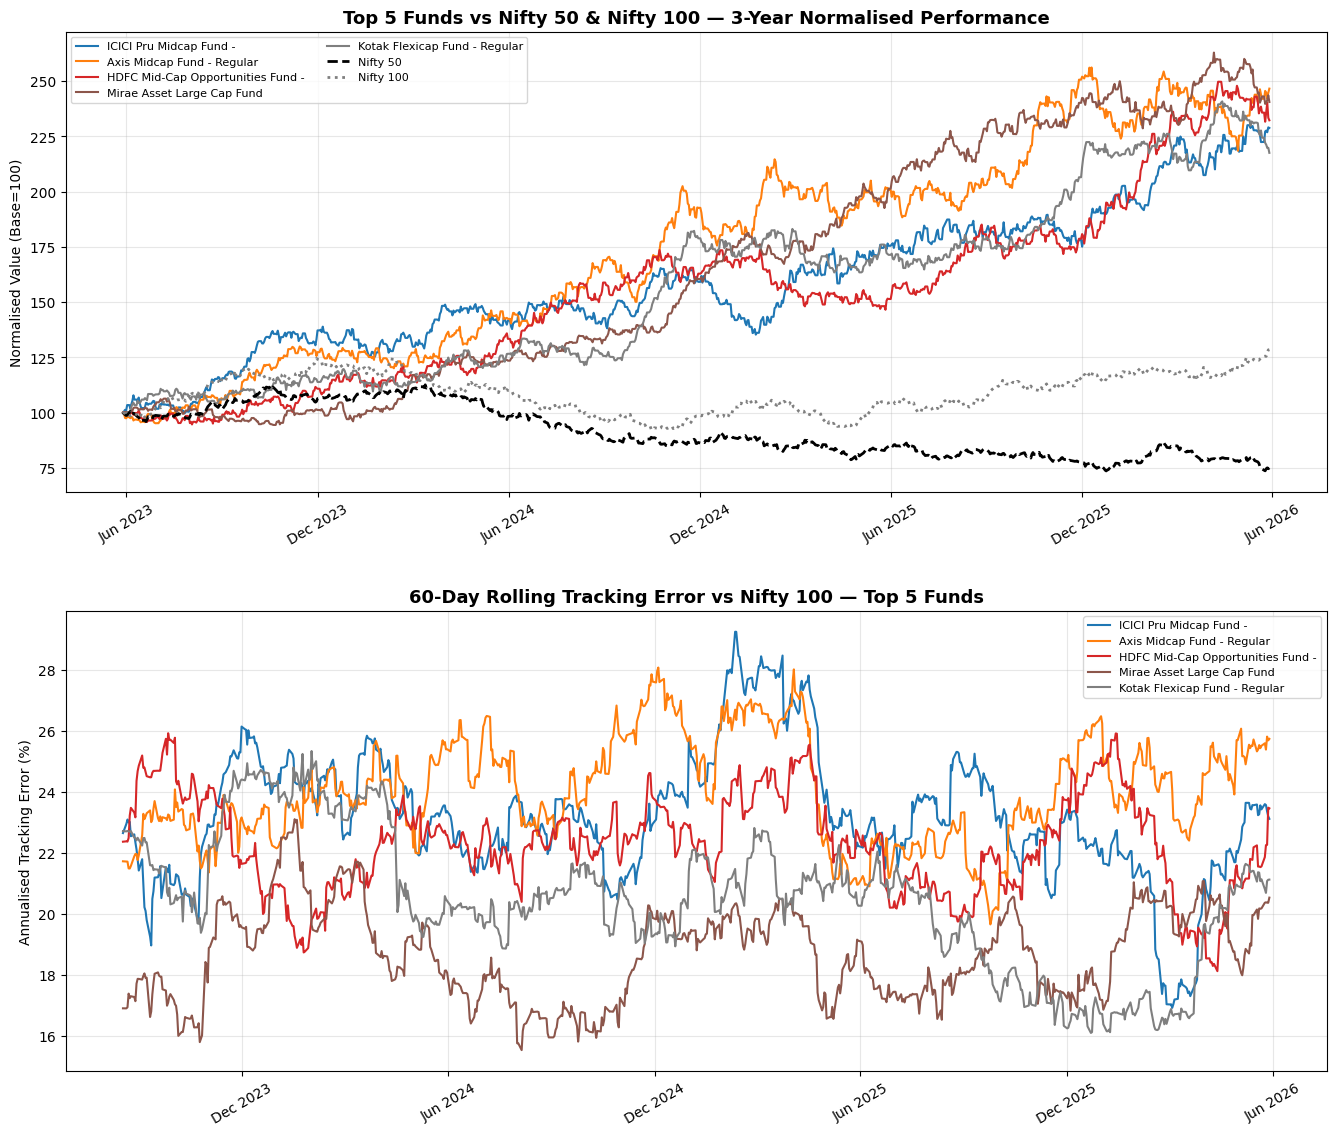

 amfi_code                                        scheme_name  tracking_error_pct_ann
    120505           ICICI Pru Midcap Fund - Regular - Growth                 23.2515
    119094                Axis Midcap Fund - Regular - Growth                 23.9658
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth                 22.4838
    148567      Mirae Asset Large Cap Fund - Regular - Growth                 18.7867
    120843             Kotak Flexicap Fund - Regular - Growth                 20.6410


In [16]:
top5_codes = sc.head(5)['amfi_code'].tolist()
top5_names = sc.head(5).set_index('amfi_code')['scheme_name'].to_dict()

cutoff_3yr = end_date - pd.DateOffset(years=3)
nifty50_b  = bench[bench['index_name']=='NIFTY50'][['date','close_value']].sort_values('date')
nifty100_b = bench[bench['index_name']=='NIFTY100'][['date','close_value']].sort_values('date')

def normalise(df, col, cutoff):
    df   = df[df['date'] >= cutoff].copy()
    base = df.iloc[0][col]
    df['norm'] = df[col] / base * 100
    return df

n50  = normalise(nifty50_b,  'close_value', cutoff_3yr)
n100 = normalise(nifty100_b, 'close_value', cutoff_3yr)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
colors = plt.cm.tab10(np.linspace(0, 0.7, 5))

ax1 = axes[0]
for code, color in zip(top5_codes, colors):
    f = nav[(nav['amfi_code']==code) & (nav['date']>=cutoff_3yr)][['date','nav']].copy()
    if f.empty: continue
    f['norm'] = f['nav'] / f.iloc[0]['nav'] * 100
    ax1.plot(f['date'], f['norm'], label=' '.join(top5_names[code].split()[:5]), color=color, linewidth=1.5)

ax1.plot(n50['date'],  n50['norm'],  label='Nifty 50',  color='black', linewidth=2, linestyle='--')
ax1.plot(n100['date'], n100['norm'], label='Nifty 100', color='gray',  linewidth=2, linestyle=':')
ax1.set_title('Top 5 Funds vs Nifty 50 & Nifty 100 — 3-Year Normalised Performance', fontsize=13, fontweight='bold')
ax1.set_ylabel('Normalised Value (Base=100)')
ax1.legend(fontsize=8, ncol=2, loc='upper left')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.grid(alpha=0.3); ax1.tick_params(axis='x', rotation=30)

ax2 = axes[1]
te_rows = []
for code, color in zip(top5_codes, colors):
    fr = nav[(nav['amfi_code']==code) & (nav['date']>=cutoff_3yr)][['date','daily_return']].copy()
    m  = fr.merge(nifty100[['date','bench_return']], on='date').dropna()
    m['excess'] = m['daily_return'] - m['bench_return']
    m['te_60d'] = m['excess'].rolling(60).std() * np.sqrt(252) * 100
    ax2.plot(m['date'], m['te_60d'], label=' '.join(top5_names[code].split()[:5]), color=color, linewidth=1.5)
    te_rows.append({'amfi_code': code, 'scheme_name': top5_names[code],
                    'tracking_error_pct_ann': round(m['excess'].std()*np.sqrt(252)*100, 4)})

ax2.set_title('60-Day Rolling Tracking Error vs Nifty 100 — Top 5 Funds', fontsize=13, fontweight='bold')
ax2.set_ylabel('Annualised Tracking Error (%)')
ax2.legend(fontsize=8, loc='upper right')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax2.grid(alpha=0.3); ax2.tick_params(axis='x', rotation=30)

plt.tight_layout(pad=3)
plt.savefig(OUT + 'benchmark_chart.png', dpi=150, bbox_inches='tight')
plt.show()

te_df = pd.DataFrame(te_rows)
te_df.to_csv(OUT + 'tracking_error.csv', index=False)

print(te_df.to_string(index=False))


---
## Day 4 Deliverables Summary
| File | Description |
|------|-------------|
| `returns_computed.csv` | Daily + annualised returns for all 40 funds |
| `cagr_report.csv` | 1yr, 3yr, 5yr CAGR per fund |
| `sharpe_values.csv` | Sharpe ratio (Rf=6.5%) |
| `sortino_values.csv` | Sortino ratio (downside std only) |
| `alpha_beta.csv` | OLS alpha & beta vs NIFTY 100 |
| `max_drawdown.csv` | Max drawdown + peak/trough dates |
| `fund_scorecard.csv` | Composite score 0-100 with ranking |
| `benchmark_chart.png` | Top 5 funds vs Nifty 50 & 100 (3yr) |